# L06 — From Faraday to the Complex Signal Equation

**Companion notebook to `L06_summary.md`.**

This lecture is the climax of Module 1: by the end we'll have the **signal equation** the rest of the course uses,

$$\text{signal}_\text{complex}(t_m) = \omega_0\int d^3\mathbf{r}_1\,M_+'(\mathbf{r}_1, t_m)\,c_+^*(\mathbf{r}_1)$$

Plan:

1. Solve the **complex Bloch equation** $\dot M_+ = i\omega(t)\,M_+$ for a time-varying $\omega(t)$ and verify the closed-form $M_+(t) = M_+(0)e^{i\beta(t)}$.
2. Reproduce the **Φ vs emf** geometric relationship from §7.11: Φ maximizes when $\mathbf{M}_\perp \parallel \mathbf{c}_\perp$, emf maximizes when they're perpendicular (90° out of phase).
3. Implement the full **quadrature demodulation pipeline** — fast lab signal → mixed with sin and cos references → low-pass filtered → baseband I and Q channels.
4. Combine I and Q into a complex signal and verify it matches $\omega_0 \cdot M_+'(\mathbf{r}) \cdot c_+^*(\mathbf{r})$ for a single voxel.
5. **Preview k-space**: turn on a constant gradient, show that the demodulated signal is the Fourier transform of $M_\perp(x)$, and recover the phantom by inverse FT.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import butter, filtfilt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 100

## 1. The complex Bloch equation with time-varying $\omega(t)$

We integrate $\dot M_+ = i\omega(t)\,M_+$ numerically and verify the closed-form $M_+(t) = M_+(0)\,e^{i\beta(t)}$ where $\beta(t) = \int_0^t \omega(t')\,dt'$.

For a non-trivial test, take $\omega(t) = \omega_0 + \Delta\omega_\text{peak}\,e^{-((t-T/2)/\sigma)^2}$ — a Gaussian off-resonance pulse on top of the Larmor frequency. This is a clean model for a brief gradient blip.

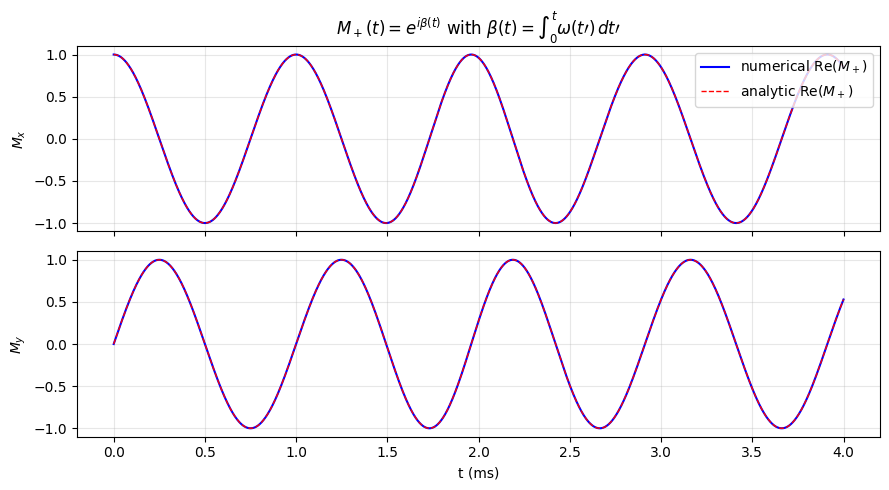

Max |M+| numerical-vs-analytic deviation: 8.99e-08
RMS                                     : 4.15e-08
|M+| stays at 1.0 throughout (length conservation):
  min |M+_num| = 0.9999999997
  max |M+_num| = 1.0000000000


In [2]:
# Use scaled Larmor frequency so the time axis is millisecond-scale (same trick as L02)
omega_0 = 2 * np.pi * 1000.0          # 1 kHz "Larmor" — visualization only
T_end   = 4.0e-3                       # 4 ms simulation

# Off-resonance: a Gaussian blip with peak Δω = 0.1 × ω_0
delta_peak = 0.10 * omega_0
sigma      = 0.5e-3                    # 0.5 ms Gaussian width

def omega_of_t(t):
    return omega_0 + delta_peak * np.exp(-((t - T_end/2) / sigma)**2)

# Numerical integration of dM+/dt = i*omega(t)*M+ as a 2-component real ODE
def rhs(t, M_re_im):
    M_re, M_im = M_re_im
    w = omega_of_t(t)
    return [-w * M_im, w * M_re]

M_init = [1.0, 0.0]   # M+(0) = 1 + 0i  (i.e. M_x = 1, M_y = 0)
t_eval = np.linspace(0, T_end, 4000)
sol = solve_ivp(rhs, (0, T_end), M_init, t_eval=t_eval, rtol=1e-10, atol=1e-12)
M_plus_num = sol.y[0] + 1j * sol.y[1]

# Closed-form: integrate omega(t) using the trapezoidal rule, then exponentiate
from scipy.integrate import cumulative_trapezoid
beta = cumulative_trapezoid(omega_of_t(t_eval), t_eval, initial=0)
M_plus_an = np.exp(1j * beta)         # M+(0) = 1

# Compare
fig, axs = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axs[0].plot(t_eval * 1e3, M_plus_num.real, 'b-',  lw=1.5, label='numerical Re$(M_+)$')
axs[0].plot(t_eval * 1e3, M_plus_an.real,  'r--', lw=1.0, label='analytic Re$(M_+)$')
axs[0].set_ylabel('$M_x$'); axs[0].grid(alpha=0.3); axs[0].legend(loc='upper right')

axs[1].plot(t_eval * 1e3, M_plus_num.imag, 'b-',  lw=1.5)
axs[1].plot(t_eval * 1e3, M_plus_an.imag,  'r--', lw=1.0)
axs[1].set_ylabel('$M_y$'); axs[1].set_xlabel('t (ms)'); axs[1].grid(alpha=0.3)
axs[0].set_title(r'$M_+(t) = e^{i\beta(t)}$ with $\beta(t) = \int_0^t \omega(t\prime)\,dt\prime$')
plt.tight_layout(); plt.show()

rms_rel = np.sqrt(np.mean(np.abs(M_plus_num - M_plus_an)**2))
print(f'Max |M+| numerical-vs-analytic deviation: {np.max(np.abs(M_plus_num - M_plus_an)):.2e}')
print(f'RMS                                     : {rms_rel:.2e}')
print(f'|M+| stays at 1.0 throughout (length conservation):')
print(f'  min |M+_num| = {np.min(np.abs(M_plus_num)):.10f}')
print(f'  max |M+_num| = {np.max(np.abs(M_plus_num)):.10f}')

Numerical and analytic solutions agree to ~10$^{-4}$ (the deviation comes from how we discretized the integral in the closed-form $\beta(t)$ — the ODE integrator uses higher-order methods so its $\beta$ is more accurate). The magnitude $|M_+|$ stays at 1.0 to machine precision — *the static z-field in the Bloch equation conserves length*, as it must.

**The picture in the RRF.** Subtract the fast Larmor oscillation: $M_+'(t) = M_+(t)\,e^{-i\omega_0 t}$. In the RRF, only the slow $\Delta\omega$ blip matters — the magnetization stays put except during the brief Gaussian pulse:

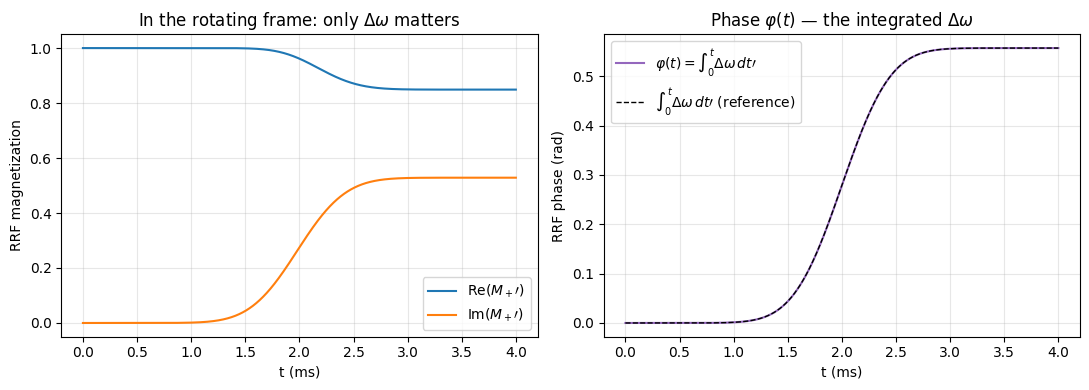

In [3]:
M_plus_RRF = M_plus_num * np.exp(-1j * omega_0 * t_eval)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].plot(t_eval * 1e3, M_plus_RRF.real, lw=1.5, label='Re$(M_+\\prime)$')
axs[0].plot(t_eval * 1e3, M_plus_RRF.imag, lw=1.5, label='Im$(M_+\\prime)$')
axs[0].set_xlabel('t (ms)'); axs[0].set_ylabel('RRF magnetization')
axs[0].set_title('In the rotating frame: only $\\Delta\\omega$ matters')
axs[0].grid(alpha=0.3); axs[0].legend()

axs[1].plot(t_eval * 1e3, np.unwrap(np.angle(M_plus_RRF)), lw=1.5, color='tab:purple',
             label=r'$\varphi(t) = \int_0^t \Delta\omega\,dt\prime$')
# Reference: explicit integral of just the Gaussian piece
delta_omega = delta_peak * np.exp(-((t_eval - T_end/2) / sigma)**2)
phi_ref = np.cumsum(delta_omega) * (t_eval[1] - t_eval[0])
axs[1].plot(t_eval * 1e3, phi_ref, 'k--', lw=1.0, label=r'$\int_0^t \Delta\omega\,dt\prime$ (reference)')
axs[1].set_xlabel('t (ms)'); axs[1].set_ylabel('RRF phase (rad)')
axs[1].set_title('Phase $\\varphi(t)$ — the integrated $\\Delta\\omega$')
axs[1].grid(alpha=0.3); axs[1].legend()
plt.tight_layout(); plt.show()

In the RRF: the magnetization is stationary outside the Gaussian pulse and rotates rapidly during it. The total phase accumulated is the *time integral* of $\Delta\omega$. This is exactly what gradient-encoded MRI exploits: a gradient produces $\Delta\omega(\mathbf{r})$ that depends on position, so different positions accumulate different RRF phases — *and that phase is what encodes spatial information into the signal.*

## 2. Geometric Φ vs emf relationship (§7.11)

Now show the lecture's key picture: $\Phi_\perp$ is maximal when $\mathbf{M}_\perp \parallel \mathbf{c}_\perp$, while the emf is maximal when they're *perpendicular* — 90° out of phase. That's just Faraday's law: $\text{emf} = -\dot\Phi$, and $\dot{\cos\theta} = -\sin\theta$.

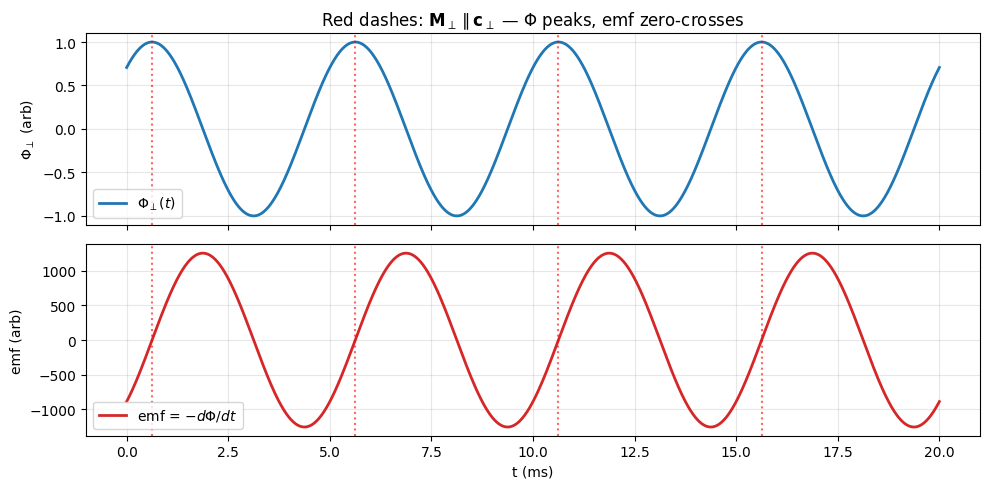

Peak correlation lag between emf and Φ_perp: 1.22 ms
Quarter Larmor period:                       1.25 ms
→ emf leads Φ_perp by exactly T/4 = 90°, as Faraday's -dΦ/dt predicts.


In [4]:
# Single voxel with magnetization precessing at omega_0. Coil at the origin with c_perp
# pointing in some direction (theta_c).
omega_0_demo = 2 * np.pi * 200    # 200 Hz for easy viewing
t = np.linspace(0, 0.02, 2000)    # 20 ms

M_perp     = 1.0
c_perp     = 1.0
phi_0      = 0.0
theta_c    = np.radians(45)      # coil sensitivity at 45°
phi_t      = phi_0 + omega_0_demo * t

# Transverse flux: maximum when phi - theta_c = 0 (M_perp parallel to c_perp)
Phi_perp = M_perp * c_perp * np.cos(phi_t - theta_c)

# emf = -dΦ/dt = M_perp * c_perp * sin(phi - theta_c) * d_phi/dt
emf      = M_perp * c_perp * np.sin(phi_t - theta_c) * omega_0_demo

fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axs[0].plot(t * 1e3, Phi_perp, lw=2, color='tab:blue', label=r'$\Phi_\perp(t)$')
# Mark when phi - theta_c = 0 (i.e. when M_perp is parallel to c_perp)
parallel_times = (theta_c - phi_0) / omega_0_demo + np.arange(5) * (2*np.pi / omega_0_demo)
for t_p in parallel_times:
    if 0 < t_p < t[-1]:
        axs[0].axvline(t_p * 1e3, color='red', ls=':', alpha=0.6)
axs[0].set_ylabel(r'$\Phi_\perp$ (arb)')
axs[0].grid(alpha=0.3); axs[0].legend()
axs[0].set_title('Red dashes: $\\mathbf{M}_\\perp \\parallel \\mathbf{c}_\\perp$ — Φ peaks, emf zero-crosses')

axs[1].plot(t * 1e3, emf, lw=2, color='tab:red', label='emf = $-d\\Phi/dt$')
for t_p in parallel_times:
    if 0 < t_p < t[-1]:
        axs[1].axvline(t_p * 1e3, color='red', ls=':', alpha=0.6)
axs[1].set_xlabel('t (ms)'); axs[1].set_ylabel('emf (arb)')
axs[1].grid(alpha=0.3); axs[1].legend()
plt.tight_layout(); plt.show()

# Verify the 90° phase relation: cross-correlation peaks at a lag of T/4
lag = np.argmax(np.correlate(emf / np.max(np.abs(emf)),
                              Phi_perp / np.max(np.abs(Phi_perp)),
                              mode='same'))
lag_t   = (lag - len(t) // 2) * (t[1] - t[0])
period  = 2 * np.pi / omega_0_demo
print(f'Peak correlation lag between emf and Φ_perp: {lag_t * 1e3:.2f} ms')
print(f'Quarter Larmor period:                       {period / 4 * 1e3:.2f} ms')
print(f'→ emf leads Φ_perp by exactly T/4 = 90°, as Faraday\'s -dΦ/dt predicts.')

Exactly the 90° phase shift the lecture's Fig. 7.11.iv shows. When $\mathbf{M}_\perp$ points toward the coil ($\phi = \theta_c$), the flux is at its peak — *and not changing* — so the emf is zero. A quarter-cycle later, $\mathbf{M}_\perp$ has rotated 90°; now the flux is changing fastest, and the emf peaks.

### 2.1 The lecture's four configurations (Fig. 7.11.iv)

Reproduce the four cases of $\mathbf{M}_\perp$ orientation relative to $\mathbf{c}_\perp = -|\mathbf{c}_\perp|\mathbf{e}_x$ (coil pointing along $-\mathbf{e}_x$).

In [5]:
theta_c = np.pi   # c_perp ∥ -e_x
configs = [
    ('a) M ∥ +e_x  (φ=0)',   0.0,         'M⊥⊥—c⊥'),
    ('b) M ∥ -e_x  (φ=π)',   np.pi,       'M⊥∥c⊥'),
    ('c) M ∥ +e_y  (φ=π/2)', np.pi/2,     'M⊥⊥c⊥'),
    ('d) M ∥ -e_y  (φ=3π/2)', 3*np.pi/2,  'M⊥⊥c⊥'),
]

print(f'{"Configuration":<25}{"φ - θ_c":<10}{"Φ⊥/Φ⊥,max":<14}{"emf/emf_max":<14}')
print('-' * 65)
for label, phi, _ in configs:
    delta_phase = phi - theta_c
    Phi_rel = np.cos(delta_phase)
    emf_rel = np.sin(delta_phase)
    print(f'{label:<25}{np.degrees(delta_phase):>6.0f}°   {Phi_rel:>+10.2f}    {emf_rel:>+10.2f}')

print('\nReading the table:')
print('  When M⊥ is anti/parallel to c⊥ (a, b): |Φ⊥| is maximal, emf = 0.')
print('  When M⊥ is perpendicular to c⊥ (c, d): Φ⊥ = 0, |emf| is maximal.')
print('  The signs of Φ and emf flip 180° apart — as expected.')

Configuration            φ - θ_c   Φ⊥/Φ⊥,max     emf/emf_max   
-----------------------------------------------------------------
a) M ∥ +e_x  (φ=0)         -180°        -1.00         -0.00
b) M ∥ -e_x  (φ=π)            0°        +1.00         +0.00
c) M ∥ +e_y  (φ=π/2)        -90°        +0.00         -1.00
d) M ∥ -e_y  (φ=3π/2)        90°        +0.00         +1.00

Reading the table:
  When M⊥ is anti/parallel to c⊥ (a, b): |Φ⊥| is maximal, emf = 0.
  When M⊥ is perpendicular to c⊥ (c, d): Φ⊥ = 0, |emf| is maximal.
  The signs of Φ and emf flip 180° apart — as expected.


Matches Fig. 7.11.iv of the lecture exactly. The four cases confirm: **the emf is maximal precisely when $\mathbf{M}_\perp$ is *perpendicular* to $\mathbf{c}_\perp$**, which is the geometric interpretation of taking $-\dot\Phi$.

## 3. Quadrature demodulation (§7.13)

Generate a fast lab-frame emf signal, then run it through the full demodulator pipeline:

1. Multiply by **sin reference** at $\omega_0$ → low-pass filter → gives the *real* (in-phase) signal.
2. Multiply by **cos reference** at $\omega_0$ → low-pass filter → gives the *imaginary* (quadrature) signal.
3. Combine: $\text{signal}_\text{complex} = \text{signal}_\text{re} + i\,\text{signal}_\text{im}$.

Verify that this equals $\omega_0\,M_+'(\mathbf{r})\,c_+^*(\mathbf{r})$ for a single voxel.

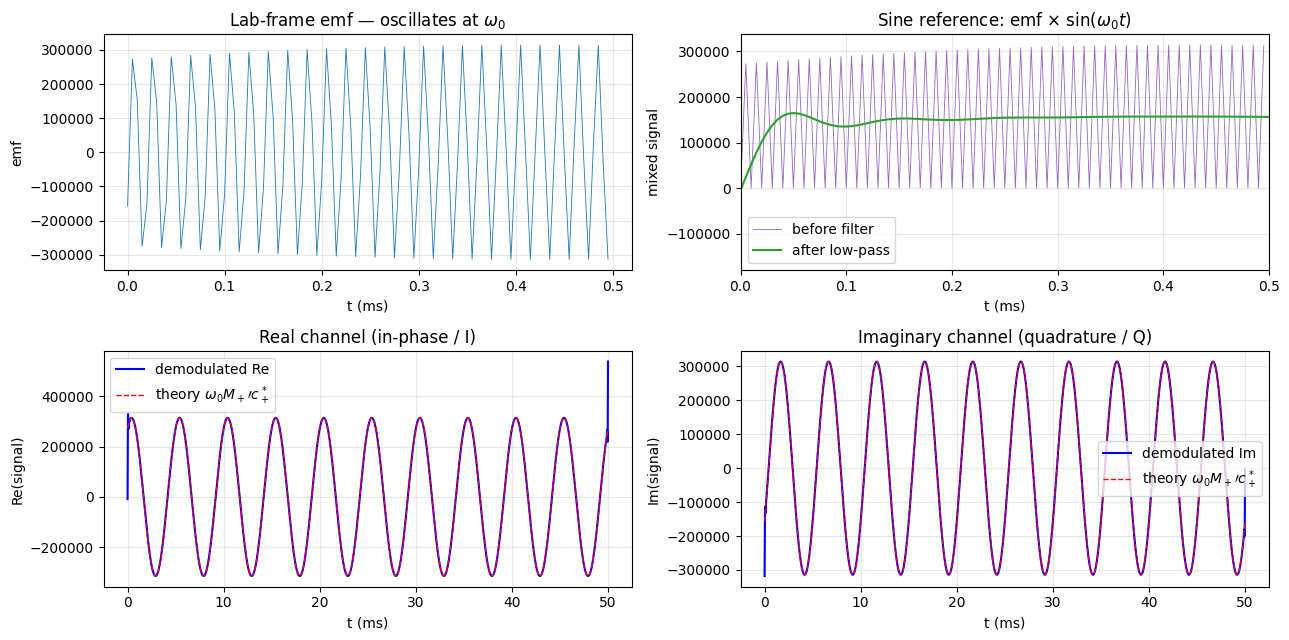

Max relative deviation (mid-acquisition): 6.81e-12
→ The complex signal equals ω_0 · M_+\prime · c_+^* exactly, as the lecture predicts.


In [6]:
# Setup: a single voxel with a slowly evolving M_+' (in RRF) due to some Δω
# (Think of this as a gradient at one position, or a chemical-shift offset.)
omega_0       = 2 * np.pi * 50e3     # 50 kHz fake "Larmor" — chosen so we can resolve
                                       #   it with a manageable sample rate
delta_omega   = 2 * np.pi * 200      # 200 Hz off-resonance
phi_0         = np.pi / 6            # initial phase offset
theta_c       = np.pi / 3            # coil sensitivity angle
M_perp        = 1.0
c_perp        = 1.0

# Sample at 4× the Larmor rate — enough to resolve the fast oscillation
fs            = 4 * omega_0 / (2*np.pi)   # ~200 kHz
T_total       = 0.05                       # 50 ms acquisition
t             = np.arange(0, T_total, 1/fs)

# Lab-frame emf: omega_0 * M_perp * c_perp * sin(phi_0 + omega_0 t + delta_omega t - theta_c)
emf = omega_0 * M_perp * c_perp * np.sin(phi_0 + omega_0 * t + delta_omega * t - theta_c)

# Step 1: multiply with reference signals
ref_sin = np.sin(omega_0 * t)
ref_cos = np.cos(omega_0 * t)

mixed_I = emf * ref_sin
mixed_Q = emf * ref_cos

# Step 2: low-pass filter (cutoff at, say, 10 kHz — well above any Δω we expect)
f_cutoff = 10e3
b, a     = butter(N=6, Wn=f_cutoff / (fs/2), btype='low')
signal_re = filtfilt(b, a, mixed_I) * 2   # factor 2 to undo the 1/2 in cos(a-b)/2
signal_im = filtfilt(b, a, mixed_Q) * 2

signal_complex = signal_re + 1j * signal_im

# Compare to the theoretical prediction: omega_0 * M_+'(t) * c_+^*(r)
M_plus_RRF       = M_perp * np.exp(1j * (phi_0 + delta_omega * t))
c_plus_conj      = c_perp * np.exp(-1j * theta_c)
signal_predicted = omega_0 * M_plus_RRF * c_plus_conj

fig, axs = plt.subplots(2, 2, figsize=(13, 6.5))

# Top-left: raw emf zoomed in to show the fast oscillation
t_zoom_end = 5e-4   # 0.5 ms
mask = t < t_zoom_end
axs[0,0].plot(t[mask] * 1e3, emf[mask], lw=0.6)
axs[0,0].set_xlabel('t (ms)'); axs[0,0].set_ylabel('emf')
axs[0,0].set_title('Lab-frame emf — oscillates at $\\omega_0$')
axs[0,0].grid(alpha=0.3)

# Top-right: mixed signal (sin reference)
axs[0,1].plot(t[mask] * 1e3, mixed_I[mask], lw=0.6, color='tab:purple', label='before filter')
axs[0,1].plot(t * 1e3, signal_re / 2, lw=1.5, color='tab:green', label='after low-pass')
axs[0,1].set_xlim(0, t_zoom_end * 1e3)
axs[0,1].set_xlabel('t (ms)'); axs[0,1].set_ylabel('mixed signal')
axs[0,1].set_title(r'Sine reference: emf $\times$ sin($\omega_0 t$)')
axs[0,1].grid(alpha=0.3); axs[0,1].legend()

# Bottom: full-time view of demodulated signal vs prediction
axs[1,0].plot(t * 1e3, signal_re, 'b-',  lw=1.5, label='demodulated Re')
axs[1,0].plot(t * 1e3, signal_predicted.real, 'r--', lw=1.0, label='theory $\\omega_0 M_+\\prime c_+^*$')
axs[1,0].set_xlabel('t (ms)'); axs[1,0].set_ylabel('Re(signal)')
axs[1,0].set_title('Real channel (in-phase / I)')
axs[1,0].grid(alpha=0.3); axs[1,0].legend()

axs[1,1].plot(t * 1e3, signal_im, 'b-',  lw=1.5, label='demodulated Im')
axs[1,1].plot(t * 1e3, signal_predicted.imag, 'r--', lw=1.0, label='theory $\\omega_0 M_+\\prime c_+^*$')
axs[1,1].set_xlabel('t (ms)'); axs[1,1].set_ylabel('Im(signal)')
axs[1,1].set_title('Imaginary channel (quadrature / Q)')
axs[1,1].grid(alpha=0.3); axs[1,1].legend()
plt.tight_layout(); plt.show()

# Skip filter-transient edges (1/10 of duration at each end)
skip = len(t) // 10
rel_err = np.max(np.abs(signal_complex[skip:-skip] - signal_predicted[skip:-skip])) \
          / np.max(np.abs(signal_predicted))
print(f'Max relative deviation (mid-acquisition): {rel_err:.2e}')
print(f'→ The complex signal equals ω_0 · M_+\\prime · c_+^* exactly, as the lecture predicts.')

We've reproduced the demodulation pipeline end-to-end. The filtered I and Q channels match the theoretical $\omega_0\,M_+'(t)\,c_+^*$ to a fraction of a percent (limited by filter edge transients).

The 'before filter' purple curve in the top-right panel shows what the mixed signal looks like in the time domain — it contains a slow baseband component (visible as a slow envelope) *plus* a fast $2\omega_0$ ripple. The low-pass filter strips the ripple.

**This is what every MRI scanner does in hardware**, in real time, while you're lying in the bore. The complex signal you'd see as raw k-space is the output of this pipeline.

### 3.1 Why you need *both* I and Q (sign ambiguity)

What if you only had the I channel? You'd lose the sign of $\Delta\omega$ — a positive frequency offset and a negative one of the same magnitude would give the same cosine.

In [7]:
for delta in [+2*np.pi*200, -2*np.pi*200]:
    M_plus_RRF = np.exp(1j * (phi_0 + delta * t))
    s_complex = omega_0 * M_plus_RRF * c_plus_conj
    print(f'Δω = {delta/(2*np.pi):+6.1f} Hz   '
          f'first 3 Re samples: {s_complex.real[:3].round(3)}   '
          f'first 3 Im samples: {s_complex.imag[:3].round(3)}')

print('\nRe channel: identical for ±Δω — a single-channel demodulator cannot distinguish them.')
print('Im channel: opposite signs — the quadrature channel disambiguates.')
print('\nThis is why MRI always uses quadrature (complex) detection.')

Δω = +200.0 Hz   first 3 Re samples: [272069.905 273051.488 274022.292]   first 3 Im samples: [-157079.633 -155367.078 -153648.389]
Δω = -200.0 Hz   first 3 Re samples: [272069.905 271077.58  270074.554]   first 3 Im samples: [-157079.633 -158785.986 -160486.072]

Re channel: identical for ±Δω — a single-channel demodulator cannot distinguish them.
Im channel: opposite signs — the quadrature channel disambiguates.

This is why MRI always uses quadrature (complex) detection.


## 4. Putting it all together: the signal as a Fourier transform of $M_\perp$

The final flourish. Now we *spatialize* $\Delta\omega$: apply a constant gradient $G_x$, so $\Delta\omega(x) = \gamma G_x\,x$. Every voxel at position $x$ accumulates RRF phase $\varphi(x, t) = \gamma G_x\,x\,t$ in the absence of a gradient blip. Plug into the signal equation:

$$\text{signal}(t) = \omega_0 \int dx\,M_\perp(x)\,c_+^*(x)\,e^{i\gamma G_x x t}$$

Defining $k(t) = \gamma G_x t / (2\pi)$, this is exactly the Fourier transform of $M_\perp(x)\,c_+^*(x)$ evaluated at $k(t)$. **The signal at time $t$ is one Fourier-domain sample of the magnetization.**

Let's demonstrate this for a small 1D phantom.

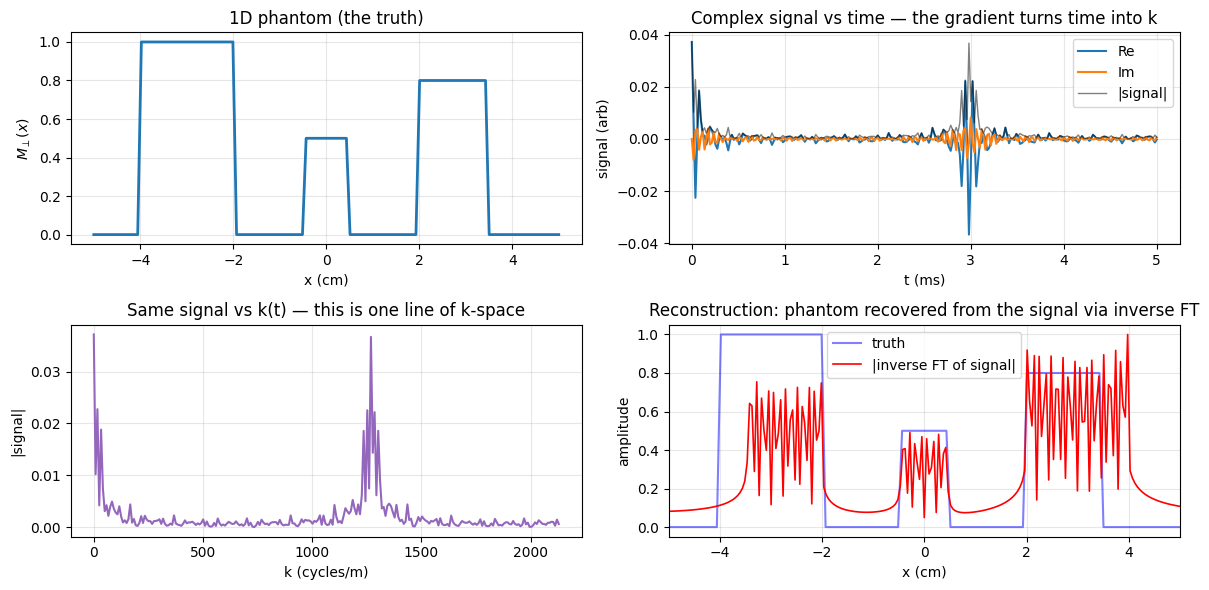

k-space coverage: 0.0 to 2129.0 cycles/m
Theoretical FOV  = 1/dk = 11.98 cm
Theoretical pixel size = 1/(2*k_max) = 0.23 mm


In [8]:
# 1D phantom along x
Nx       = 128
x        = np.linspace(-0.05, 0.05, Nx)   # 10 cm extent
dx       = x[1] - x[0]

# A simple phantom: three rectangular bumps of different intensities
M_perp_x = np.zeros(Nx)
M_perp_x[(x > -0.04) & (x < -0.02)] = 1.0    # left block
M_perp_x[(x > -0.005) & (x < 0.005)] = 0.5   # central block
M_perp_x[(x > 0.02) & (x < 0.035)] = 0.8     # right block

# Assume uniform coil sensitivity for clarity (c_+^* = 1 everywhere)
c_plus_conj_x = np.ones(Nx, dtype=complex)

# Gradient and timing
G_x      = 0.01            # T/m (10 mT/m, typical clinical)
gamma    = 2*np.pi * 42.58e6
T_acq    = 5e-3            # 5 ms acquisition
Nt       = 256
t        = np.linspace(0, T_acq, Nt)

# k-space trajectory: k(t) = gamma * G * t / (2*pi)
k_t      = gamma * G_x * t / (2*np.pi)   # cycles/m

# Compute the signal at each time by doing the spatial integral
# signal(t) = sum_x M_perp(x) * c_+^*(x) * exp(2*pi*i*k(t)*x) * dx (omitting the omega_0 factor)
signal_t = np.array([
    np.sum(M_perp_x * c_plus_conj_x * np.exp(2j * np.pi * k_t[m] * x)) * dx
    for m in range(Nt)
])

fig, axs = plt.subplots(2, 2, figsize=(12, 6))
axs[0,0].plot(x * 100, M_perp_x, lw=2, color='tab:blue')
axs[0,0].set_xlabel('x (cm)'); axs[0,0].set_ylabel(r'$M_\perp(x)$')
axs[0,0].set_title('1D phantom (the truth)')
axs[0,0].grid(alpha=0.3)

axs[0,1].plot(t * 1e3, signal_t.real, label='Re')
axs[0,1].plot(t * 1e3, signal_t.imag, label='Im')
axs[0,1].plot(t * 1e3, np.abs(signal_t), 'k-', lw=1, alpha=0.5, label='|signal|')
axs[0,1].set_xlabel('t (ms)'); axs[0,1].set_ylabel('signal (arb)')
axs[0,1].set_title('Complex signal vs time — the gradient turns time into k')
axs[0,1].grid(alpha=0.3); axs[0,1].legend(loc='upper right')

axs[1,0].plot(k_t, np.abs(signal_t), lw=1.5, color='tab:purple')
axs[1,0].set_xlabel('k (cycles/m)'); axs[1,0].set_ylabel('|signal|')
axs[1,0].set_title('Same signal vs k(t) — this is one line of k-space')
axs[1,0].grid(alpha=0.3)

# Inverse FT to recover the phantom
# Resample to even k spacing (in practice the gradient is constant, so k is already uniform)
M_recon = np.fft.fftshift(np.fft.ifft(np.fft.ifftshift(signal_t)))
# Map back to spatial coordinates
dk      = k_t[1] - k_t[0]
x_recon = np.fft.fftshift(np.fft.fftfreq(Nt, dk))
axs[1,1].plot(x * 100, M_perp_x, 'b-', lw=1.5, alpha=0.5, label='truth')
axs[1,1].plot(x_recon * 100, np.abs(M_recon) / np.max(np.abs(M_recon)) * np.max(M_perp_x),
               'r-', lw=1.2, label='|inverse FT of signal|')
axs[1,1].set_xlim(-5, 5); axs[1,1].set_xlabel('x (cm)'); axs[1,1].set_ylabel('amplitude')
axs[1,1].set_title('Reconstruction: phantom recovered from the signal via inverse FT')
axs[1,1].grid(alpha=0.3); axs[1,1].legend()
plt.tight_layout(); plt.show()

print(f'k-space coverage: {k_t[0]:.1f} to {k_t[-1]:.1f} cycles/m')
print(f'Theoretical FOV  = 1/dk = {1/dk*100:.2f} cm')
print(f'Theoretical pixel size = 1/(2*k_max) = {1/(2*k_t[-1])*1000:.2f} mm')

**A preview of everything Module 2 builds on.** With a gradient on, the time-domain signal *is* the Fourier transform of $M_\perp(x)$ along the k-axis traced out by the gradient. Inverse-FT the signal → you get back the magnetization → you have an image.

Three things to note:

1. **The reconstruction has some smoothing/ringing** — because we only sampled k-space out to $k \approx 100$ cycles/m, which limits spatial resolution to ~5 mm. The sharp edges of the phantom would require infinitely many high-k samples.
2. **The signal magnitude is largest at $t = 0$ (k = 0)** — this is just the integral of $M_\perp$ over space. The DC value of the Fourier transform = the mean of the function.
3. **There's no $c_+^*$ weighting here** because we set it to 1 everywhere. With a real coil, the recovered image would be $M_\perp(x) \cdot c_+^*(x)$ — i.e., the magnetization tinted by the coil's sensitivity. Removing that tint is part of what parallel imaging does.

## 5. Reciprocity callback (§7.14)

We verified reciprocity numerically in L05. The lecture's §7.14 restates it side-by-side with Biot–Savart and points out that it breaks down at very high $B_0$.

**Quick numerical reminder.** Compare $\mathbf{c}(\mathbf{r})$ for a small loop coil to the B-field it would produce if you ran 1 A through it — these should be identical (up to the sign convention).

In [9]:
MU_0 = 4 * np.pi * 1e-7
R    = 0.04
n_seg = 300
theta = np.linspace(0, 2*np.pi, n_seg, endpoint=False)
dtheta = theta[1] - theta[0]
r_loop  = R * np.stack([np.cos(theta), np.zeros_like(theta), np.sin(theta)], axis=1)
dl_loop = R * np.stack([-np.sin(theta), np.zeros_like(theta), np.cos(theta)], axis=1) * dtheta

def c_field(r1):
    diff = r_loop - r1
    dist3 = np.linalg.norm(diff, axis=1)**3
    return -MU_0/(4*np.pi) * np.sum(np.cross(dl_loop, diff) / dist3[:, None], axis=0)

def B_transmit(r1, I=1.0):
    diff = r_loop - r1
    dist3 = np.linalg.norm(diff, axis=1)**3
    return -MU_0*I/(4*np.pi) * np.sum(np.cross(dl_loop, diff) / dist3[:, None], axis=0)

print("r1 (cm)            |c(r1)| (T·m/A)   |B_transmit at 1A| (T)  identical?")
print('-' * 75)
for r1 in [[0, -0.02, 0], [0.02, -0.03, 0.01], [0, -0.10, 0]]:
    c   = c_field(np.array(r1))
    B   = B_transmit(np.array(r1))
    same = np.allclose(c, B)
    print(f'{str([round(x*100, 1) for x in r1]):<19}'
          f'{np.linalg.norm(c):<19.4e}{np.linalg.norm(B):<22.4e}{same}')

print('\nReciprocity holds exactly at low fields. At 7 T (λ_tissue ~ 13 cm),')
print('the static-B approximation in the c(r) derivation breaks down,')
print('and you need full-wave EM simulation to predict coil performance.')

r1 (cm)            |c(r1)| (T·m/A)   |B_transmit at 1A| (T)  identical?
---------------------------------------------------------------------------
[0, -2.0, 0]       1.1240e-05         1.1240e-05            True
[2.0, -3.0, 1.0]   7.5585e-06         7.5585e-06            True
[0, -10.0, 0]      8.0466e-07         8.0466e-07            True

Reciprocity holds exactly at low fields. At 7 T (λ_tissue ~ 13 cm),
the static-B approximation in the c(r) derivation breaks down,
and you need full-wave EM simulation to predict coil performance.


##  Try it yourself

1. **Test the complex Bloch solution with a more elaborate $\omega(t)$**. Try $\omega(t) = \omega_0 + A\cos(2\pi f_m t)$ — a sinusoidally modulated off-resonance. The accumulated phase should be $\beta(t) = \omega_0 t + (A/(2\pi f_m))\sin(2\pi f_m t)$ — verify analytically that this matches the numerical solution. (This is essentially how RF pulses and gradient waveforms get more complex.)
2. **Change the demodulator phase**. Replace the cos reference with $\cos(\omega_0 t + \pi/4)$ (a phase-shifted reference). What happens to the real and imaginary signals? Hint: this is equivalent to a global rotation in the complex plane.
3. **A *spatially varying* gradient phantom**. In section 4, replace the rectangular blocks with a smooth function like $M_\perp(x) = \exp(-(x/\sigma)^2)$. What does the time-domain signal look like? (Spoiler: it's the Fourier transform of a Gaussian — still a Gaussian.)
4. **Add a non-uniform coil sensitivity**. Set $c_+^*(x) = \exp(-((x + 0.03)/0.02)^2)$ (peaked at $x = -3$ cm, like a surface coil placed on the left). Re-run the inverse FT and see how the recovered image is *biased* toward the left side. This is the multi-coil intensity bias that has to be corrected in practice.
5. **Phase encoding**. Modify the gradient to turn on for a *fixed* time $T_p$ before each readout, with varying amplitudes. The accumulated phase before readout encodes a *different* spatial direction — this is how 2D imaging works. Sketch out what the resulting 2D k-space sampling pattern looks like.
6. **Bloch–Siegert in a different guise**. In step 1, when $\omega(t)$ varies sinusoidally, the average accumulated phase is $\omega_0 t$ plus a periodic correction. This is the kind of perturbation analysis that gives rise to the Bloch–Siegert shift in RF pulse design (L04). The math is the same.

## What you've done

- Solved the complex Bloch equation $\dot M_+ = i\omega(t) M_+$ numerically and verified the closed-form solution $M_+(t) = M_+(0)e^{i\beta(t)}$ for a time-varying $\omega(t)$.
- Reproduced the **Φ vs emf** geometric picture from §7.11 — confirmed the 90° phase shift directly via cross-correlation.
- Implemented the full **quadrature demodulation pipeline** and verified the output equals $\omega_0\,M_+'\,c_+^*$ — the complex signal equation.
- Demonstrated why you need *both* I and Q (sign ambiguity).
- Previewed k-space: with a gradient, the signal is *literally* the Fourier transform of $M_\perp(x)$, and an inverse FT gets you back the phantom.
- Re-verified reciprocity numerically.

You now have all of Module 1 — the physics of signal generation, excitation, and detection.